# Project: System ID Using Convex Optimization

## Step 1: Importing libraries!

Description:

---

1. CasADi: Library for framing the Non-Linear Program and solving it using an Interior Point Method Optimizer. Importing as * so I don't have to define the library functions. 
2. Matplotlib: Library for plotting the results/data.
3. Pandas: Read csv/excel data sheets. Used for importing the true data derived from the Gazebo Simulator!
4. Numpy: Basic array/matrices library in python. 

In [1]:
from casadi import *
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
## Standard parameters
M = 0.1
m = 1
I = 0.03
l = 0.3/2
b = 0.01
g = 9.81

den = I * (M + m) + M * m * l**2

A_up = np.array([
    [0, 0, 1, 0],
    [0, 0, 0, 1],
    [0, (-m**2 * g * l**2) / den, -(I + m * l**2) * b / den, 0],
    [0, (m * g * l * (M + m)) / den, m * l * b / den, 0]
])

B_up = np.array([
    [0],
    [0],
    [(I+m*l**2)/den],
    [-m*l/den]
])
u,_ = np.linalg.eig(A_up)
print(u)
print(A_up)
print(B_up)

[ 0.          6.7734701  -6.77927281 -0.0090909 ]
[[ 0.00000000e+00  0.00000000e+00  1.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]
 [ 0.00000000e+00 -6.26170213e+00 -1.48936170e-02  0.00000000e+00]
 [ 0.00000000e+00  4.59191489e+01  4.25531915e-02  0.00000000e+00]]
[[ 0.        ]
 [ 0.        ]
 [ 1.4893617 ]
 [-4.25531915]]


In [3]:
den = I * (M + m) + M * m * l**2

A_down = np.array([
    [0, 0, 1, 0],
    [0, 0, 0, 1],
    [0, - (m**2 * g * l**2) / den, - (I + m * l**2) * b / den, 0],
    [0, - (m * g * l * (M + m)) / den, - m * l * b / den, 0]
])

B_down = np.array([
    [0],
    [0],
    [(I + m * l**2) / den],
    [m * l / den]
])
u,_ = np.linalg.eig(A_down)
print(u)
print(A_down)

[ 0.        +0.j         -0.00290135+6.77636243j -0.00290135-6.77636243j
 -0.00909092+0.j        ]
[[ 0.00000000e+00  0.00000000e+00  1.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]
 [ 0.00000000e+00 -6.26170213e+00 -1.48936170e-02  0.00000000e+00]
 [ 0.00000000e+00 -4.59191489e+01 -4.25531915e-02  0.00000000e+00]]


## Step 2: Importing the true data from the Gazebo Simulator!

In [7]:
# Read the excel data!
true_data = pd.read_excel('pi_angle.xlsx', header = 0)

# Displaying the first 5 rows of the data!
display(true_data.head(5))

,__time,time,theta_dot,theta,input,prismatic_pos,prismatic_vel
0,1.745897e+09,0.00000,0.000000,0.000000,0.5,8.150000e-07,0.000815
1,1.745897e+09,0.00211,NaN,NaN,0.5,NaN,NaN
2,1.745897e+09,0.00217,-0.000159,-0.000012,NaN,NaN,NaN
3,1.745897e+09,0.00218,NaN,NaN,NaN,2.443000e-06,0.001628
4,1.745897e+09,0.00337,NaN,NaN,NaN,4.883000e-06,0.002440


Lets plot some of the data to see the controlled inverted pendulum in action!

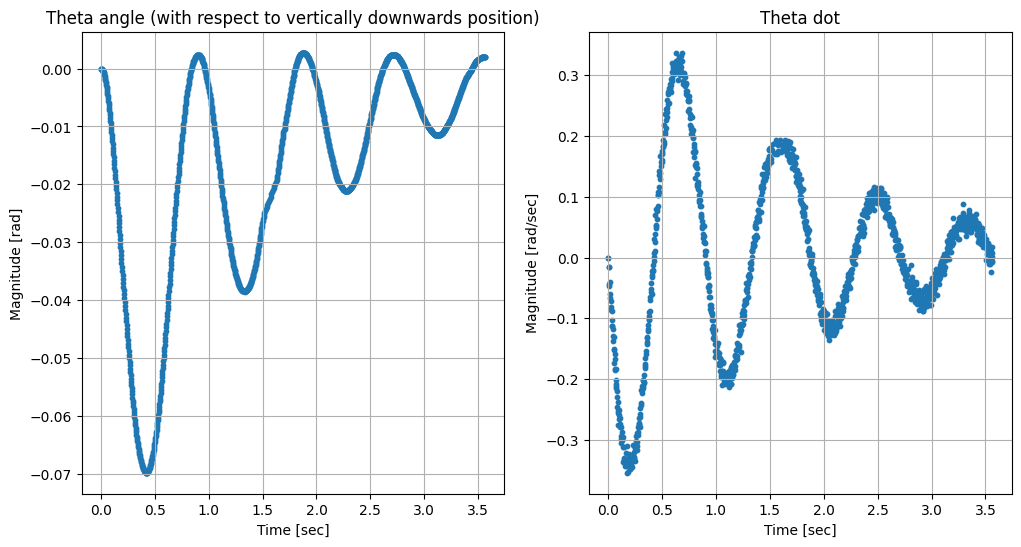

In [8]:
# Plotting
plt.figure(figsize = (12,6))

plt.subplot(1,2,1)
plt.scatter(true_data.iloc[:,1], true_data.iloc[:,3], s = 10)
plt.grid()
plt.title('Theta angle (with respect to vertically downwards position)')
plt.xlabel('Time [sec]')
plt.ylabel('Magnitude [rad]')

plt.subplot(1,2,2)
plt.scatter(true_data.iloc[:,1], true_data.iloc[:,2], s = 10)
plt.grid()
plt.title('Theta dot')
plt.xlabel('Time [sec]')
plt.ylabel('Magnitude [rad/sec]')
plt.show()

# Step 3: Interpolate between the data to get the missing values. 

Performing optimization on NaN is not going to lead the solver in the wrong direction. 

In [9]:
# Interpolating along the columns (axis = 0)
true_data = true_data.interpolate(axis = 0)

display(true_data.head(5))

,__time,time,theta_dot,theta,input,prismatic_pos,prismatic_vel
0,1.745897e+09,0.00000,0.000000,0.000000,0.5,8.150000e-07,0.000815
1,1.745897e+09,0.00211,-0.000079,-0.000006,0.5,1.357667e-06,0.001086
2,1.745897e+09,0.00217,-0.000159,-0.000012,0.5,1.900333e-06,0.001357
3,1.745897e+09,0.00218,-0.004172,-0.000019,0.5,2.443000e-06,0.001628
4,1.745897e+09,0.00337,-0.008186,-0.000026,0.5,4.883000e-06,0.002440


Fixing the theta angle shift: local body frame => global inertial frame

# Step 4: Defining the structure of the NLP (optimization problem)

(a). Defining the variable initializations!

In [10]:
# Number of states = 4
n_states = 4
n_control = 1

# Defining the decision variables: A and B matrices
A = SX.sym('X',n_states,n_states)
B = SX.sym('U',n_states,n_control)

# Defining the PD matrix for the cost function!
Q = DM.eye(n_states)

(b) Defining the dynamics!

(c) Defining the Cost Function!

In [11]:
# Initialize the cost function!
cost = 0

# Using a for loop to sum up the entire cost function!
for i in range(len(true_data)-1):

    # Get the delta_t
    dt = true_data.iloc[i+1,1] - true_data.iloc[i,1]

    # Get the current state
    curr_state = DM([
        [true_data.iloc[i,5]], [true_data.iloc[i,3]], [true_data.iloc[i,6]], [true_data.iloc[i,2]]
    ])

    # Get the next state
    true_next_state = DM([
        [true_data.iloc[i+1,5]], [true_data.iloc[i+1,3]], [true_data.iloc[i+1,6]], [true_data.iloc[i+1,2]]
    ])

    # Get the current input!
    curr_input = DM([
        [true_data.iloc[i,4]]
    ])
    # Get the estimate of the next state!
    predicted_state = curr_state + dt*(A @ curr_state + B @ curr_input)
    
    # Find the error
    err = true_next_state - predicted_state

    # Update the cost function!
    cost += err.T @ Q @ err

In [12]:
# Define the constraints on the decision variables
lbw = DM(-40 * DM.ones(20, 1))
ubw = DM(40 * DM.ones(20, 1))

(e) Defining a callback function to get the cost for every iteration

(e) Defining the NLP problem in casADi!

In [13]:
# Define the NLP problem in casADi. 

# Flatten the decision variables of the A and B matrices!
opt_vars = vertcat(A.reshape((-1, 1)), B.reshape((-1, 1)))

# Initialize a dictionary that contains the nlp problem
nlp_prob = {}
nlp_prob['x'] = opt_vars
nlp_prob['f'] = cost

# Create the callback
# cb = IterationCallback(f_cost_eval, 20)

# Define the additional parameters for the solver!
opts = {
    "ipopt.print_level": 0,
    "print_time": False,
    "ipopt.tol": 1e-6,
    "ipopt.dual_inf_tol": 1e-6,
    "ipopt.constr_viol_tol": 1e-6,
    "ipopt.compl_inf_tol": 1e-6,
    "ipopt.acceptable_tol": 1e-5,
    "ipopt.acceptable_obj_change_tol": 1e-6,
}

# Initializing the solver with Interior Point Method!
solver = nlpsol('solver','ipopt',nlp_prob, opts)

(f) Running the optimization routine!

In [ ]:
# Provide the initial guesses!
A0 = 1*np.ones((4,4))
B0 = 1*np.ones((4,1))

x0 = np.concatenate([A0.flatten(), B0.flatten()])

# Run the Optimization Routine!
sol = solver(x0=x0, lbx=lbw, ubx=ubw)


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************



In [15]:
# Extract solution
x_opt = sol['x']
A_opt = np.array(x_opt[:n_states * n_states]).reshape(n_states, n_states)
B_opt = np.array(x_opt[n_states * n_states:]).reshape(n_states, n_control)

print("Estimated A:\n", A_opt)
print("Estimated B:\n", B_opt)
print("Cost:", float(sol['f']))
print("Solver status:", solver.stats()['return_status'])
print('Iteration count:', solver.stats()['iter_count'])

Estimated A:
 [[ 2.75895440e-02  1.78045869e-02  2.94292653e-02 -1.36864959e-01]
 [ 6.88864742e-02 -1.53045240e-01  4.09526479e+00 -3.99775545e+01]
 [ 4.23582258e-01 -1.53938022e-02 -9.22744556e-01  3.84993272e+00]
 [-2.01437054e-02  4.79653488e-01  1.93359334e-02 -8.37956846e-01]]
Estimated B:
 [[ 0.01943028]
 [-0.01140911]
 [ 0.8589672 ]
 [-3.69622097]]
Cost: 0.08173351766004197
Solver status: Solve_Succeeded
Iteration count: 9


# Step 5: Model Validation

Lets take a look at the closed and open loop poles

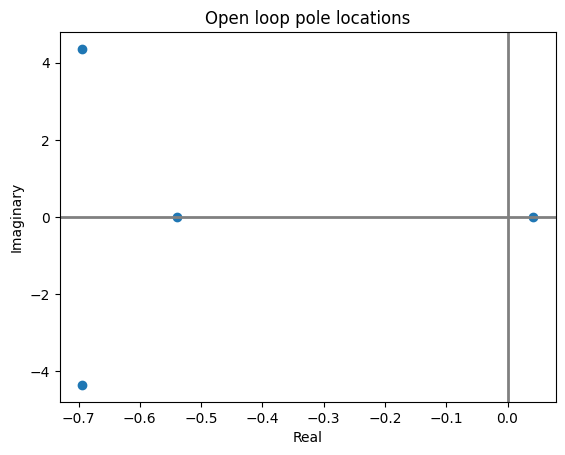

In [16]:
# Get the eigenvalues of the open and closed loop dynamics!
dt = 0.0087

# A_opt, B_opt = discrete_to_continuous(A_opt, B_opt, dt)

open_loop_eig,_ = np.linalg.eig(A_opt)
# closed_loop_eig,_ = np.linalg.eig(A_opt - B_opt@K)

plt.figure()
plt.axhline(0, color='gray', linewidth=2)
plt.axvline(0, color='gray', linewidth=2)
plt.scatter(np.real(open_loop_eig), np.imag(open_loop_eig), label='Open loop poles')
# plt.scatter(np.real(closed_loop_eig), np.imag(closed_loop_eig), label='Closed loop poles')
plt.xlabel("Real")
plt.ylabel("Imaginary")
plt.title("Open loop pole locations")
plt.show()

Test 1: Lets integrate the model to see if the pendulum has any swinging motion when no force is applied!

In [17]:
stable = pd.read_excel('stable.xlsx', header = 0)
stable = stable.interpolate(axis = 0)

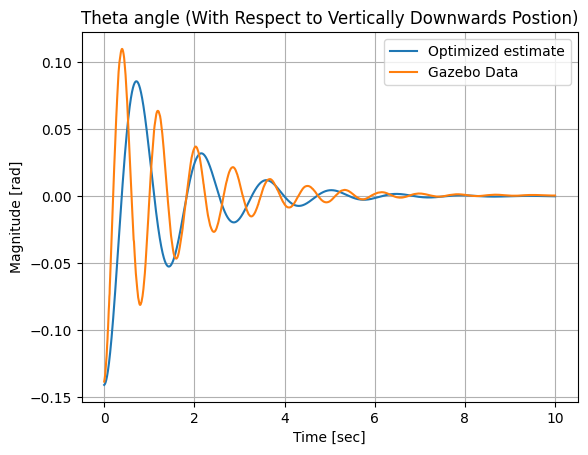

In [18]:
# Writing a function to integrate because it will be done a couple of times()
def integrate(t,A, B,u, initial_conditions):

    # Define the time array!
    time = np.linspace(0,t,10000)

    # Time step
    dt = time[1] - time[0]

    # Defining a zeros matrix to store the integrated states!
    integrated_states = np.zeros((n_states,len(time)))
    integrated_states[:,0] = initial_conditions.squeeze()

    # Run the integral!
    for i in range(len(time)-1):
        x_dot = A @ (integrated_states[:,i].reshape(4,1)) + B @ u
        next_state = integrated_states[:,i].reshape(4,1) + dt * x_dot
        integrated_states[:,i+1] = next_state.squeeze()

    return time, integrated_states

# Defining the initial conditions for the free swinging motion!
initial_conditions = np.array([
    [0], # Cart position
    [-.141], # Theta angle
    [0], # Cart velocity
    [0] # Cart Speed
])

# Define the force function!
u = np.array([
    [0]
])

# Call the function!
time,integrated_states = integrate(10,A_opt,B_opt,u, initial_conditions)
time, estimated_states = integrate(10,A_down, B_down, u, initial_conditions)
# Plotting
plt.figure()
plt.plot(time,integrated_states[1,:], label = 'Optimized estimate')
# plt.plot(time,estimated_states[1,:], label = 'Theoretical estimate')
plt.plot(stable.iloc[:,1], stable.iloc[:,2]-.141, label = 'Gazebo Data')
plt.grid()
plt.title('Theta angle (With Respect to Vertically Downwards Postion)')
plt.xlabel('Time [sec]')
plt.ylabel('Magnitude [rad]')
plt.legend()

Text(0.5, 1.0, 'Validation of 20 Models with Randomized Constraints')

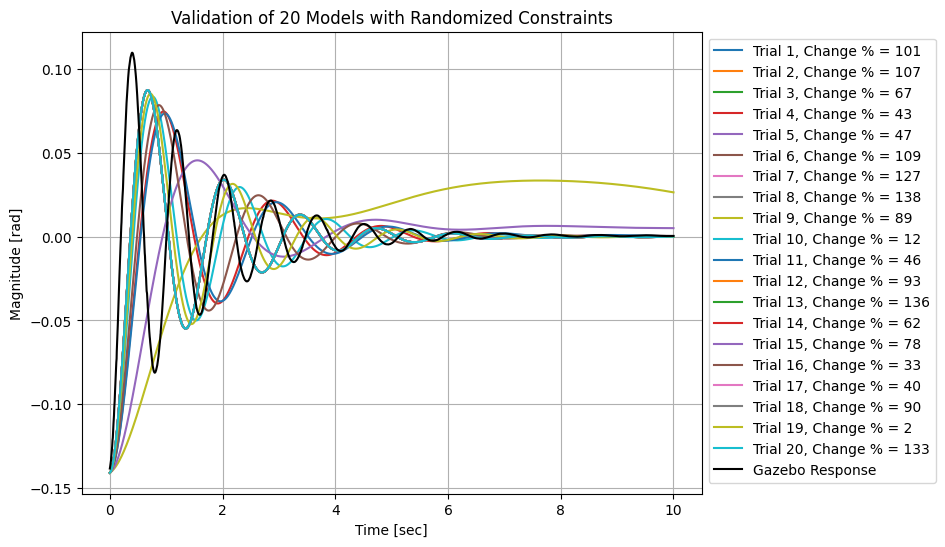

In [62]:
plt.figure(figsize = (8,6))
for i in range(20):
    change = 100*np.random.rand()
    A0 = np.random.rand(4,4)
    B0 = np.random.rand(4,1)
    x0 = np.concatenate([A0.flatten(), B0.flatten()])
    lbw = DM(-change * DM.ones(20, 1))
    ubw = DM(change * DM.ones(20, 1))
    # Run the Optimization Routine!
    sol = solver(x0=x0, lbx = lbw, ubx = ubw)

    # Extract solution
    x_opt = sol['x']
    A_opt = np.array(x_opt[:n_states * n_states]).reshape(n_states, n_states)
    B_opt = np.array(x_opt[n_states * n_states:]).reshape(n_states, n_control)
    
    time,integrated_states = integrate(10,A_opt,B_opt,u, initial_conditions)
    plt.plot(time,integrated_states[1,:], label = f'Trial {i+1}, Change % = {int(100*abs(change-40)/40)}')
plt.plot(stable.iloc[:,1], stable.iloc[:,2] -.141, label = 'Gazebo Response', color = 'black')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid()
plt.xlabel('Time [sec]')
plt.ylabel('Magnitude [rad]')
plt.title('Validation of 20 Models with Randomized Constraints')

Text(0.5, 1.0, 'Cost Percentage Change for 20 Random Constraints')

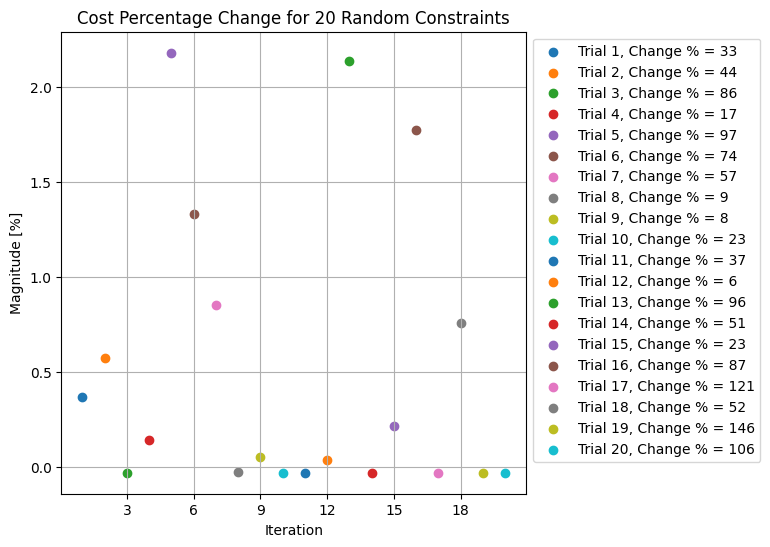

In [55]:
from matplotlib.ticker import MaxNLocator
plt.figure(figsize = (6,6))
for i in range(20):
    change = 100*np.random.rand()
    A0 = 1*np.ones((4,4))
    B0 = 1*np.ones((4,1))
    x0 = np.concatenate([A0.flatten(), B0.flatten()])

    lbw = DM(-change * DM.ones(20, 1))
    ubw = DM(change * DM.ones(20, 1))
    # Run the Optimization Routine!
    sol = solver(x0=x0, lbx = lbw, ubx = ubw)

    # Extract solution
    x_opt = sol['x']
    A_opt = np.array(x_opt[:n_states * n_states]).reshape(n_states, n_states)
    B_opt = np.array(x_opt[n_states * n_states:]).reshape(n_states, n_control)
    
    # time,integrated_states = integrate(10,A_opt,B_opt,u, initial_conditions)
    # plt.plot(time,integrated_states[1,:], label = f'Trial {i}')
    plt.scatter(i+1,100*(sol['f'].full()-0.08173351766004197)/0.08173351766004197, label = f'Trial {i+1}, Change % = {int(abs(100*(change-40)/40))}')
# plt.plot(stable.iloc[:,1], stable.iloc[:,2] -.141, label = 'Gazebo Response', color = 'black')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid()
plt.xlabel('Iteration')
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.ylabel('Magnitude [%]')
plt.title('Cost Percentage Change for 20 Random Constraints')

Lets plot the position and velocity of the cart with force = 1 N

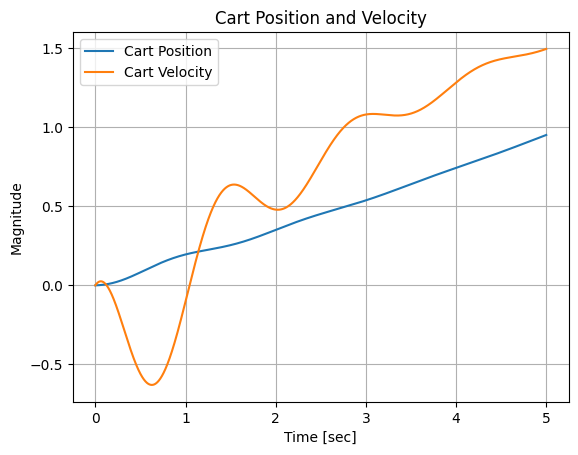

In [175]:
# Define the initial conditions!
initial_conditions = np.zeros((4,1))

# Define the control input!
u = np.array([
    [1]
])

# Integrate!
time, integrated_states = integrate(5,A_opt,B_opt,u, initial_conditions)

# Plotting!
plt.figure()
plt.plot(time,integrated_states[0,:], label = 'Cart Position')
plt.plot(time,integrated_states[2,:], label = 'Cart Velocity')
plt.legend()
plt.grid()
plt.title('Cart Position and Velocity')
plt.xlabel('Time [sec]')
plt.ylabel('Magnitude')
plt.show()